# ACTIVIDAD 2: REDES NEURONALES CONVOLUCIONALES

---

En esta actividad, vamos a trabajar con Convolutional Neural Networks para resolver un problema de clasificación de imágenes. En particular, vamos a clasificar diez clases que incluyen fundamentalmente animales y vehículos.

Como las CNN profundas son un tipo de modelo bastante avanzado y computacionalmente costoso, se recomienda hacer la práctica en Google Colaboratory con soporte para GPUs. En [este enlace](https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) se explica cómo activar un entorno con GPUs. *Nota: para leer las imágenes y estandarizarlas al mismo tamaño se usa la librería opencv. Esta ĺibrería está ya instalada en el entorno de Colab, pero si trabajáis de manera local tendréis que instalarla.*

<center><img src="https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png" style="text-align: center" height="300px"></center>

El dataset a utilizar consiste en 60000 imágenes a color de 10 clases de animales y vehículos. El dataset en cuestión se denomina [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) y es más complejo que el dataset MNIST que hemos utilizado en la actividad 1. Aunque tiene las mismas clases (10), los animales y vehículos pueden aparecer en distintas poses, en distintas posiciones de la imagen o con otros animales/ vehículos en pantalla (si bien el elemento a clasificar siempre aparece en la posición predominante).

## Carga de los datos

In [1]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import pandas as pd
import keras.datasets.cifar10 as cifar10
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from keras.utils import to_categorical
from tensorflow.keras import layers, regularizers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


In [2]:
# Primero, definimos los datos de entrenamiento, validación y prueba
(X, Y), (x_test, y_test) = cifar10.load_data()
(x_train, x_valid) = (X[:40000], X[40000:])
(y_train, y_valid) = (Y[:40000], Y[40000:])

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 337s 2us/step


In [3]:
# Normalizamos como de costumbre
x_train = x_train / 255.
x_valid = x_valid / 255.
x_test = x_test / 255.

In [4]:
# Esta variable contiene un mapeo de número de clase a elemento (animal o vehículo).
# La incluimos para ayudarte con la identificación de clases. De ti depende
# si quieres utilizar esta variable o no
MAP_ELEMENTS = {
    0: 'avion', 1: 'coche', 2: 'ave',
    3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
    7: 'caballo', 8: 'barco', 9: 'camion'
}

In [5]:
# Función auxiliar para convertir las etiquetas a codificación one-hot
def convert_to_one_hot(labels, num_classes):
    return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

# Convertimos las etiquetas de entrenamiento, validación y prueba
num_classes = 10
y_train_one_hot = convert_to_one_hot(y_train, num_classes)
y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
y_test_one_hot = convert_to_one_hot(y_test, num_classes)

# Verificamos las conversiones
print(y_train_one_hot.shape)
print(y_valid_one_hot.shape)
print(y_test_one_hot.shape)

(40000, 10)
(10000, 10)
(10000, 10)


## Ejercicio

Utilizando Convolutional Neural Networks con Keras, entrenar un clasificador que sea capaz de reconocer una imagen de las incluidas en CIFAR-10 con la mayor accuracy posible. Redactar un informe analizando varias de las alternativas probadas y los resultados obtenidos.

A continuación se detallan una serie de aspectos orientativos que podrían ser analizados en vuestro informe (no es necesario tratar todos ellos ni mucho menos, esto son ideas orientativas de aspectos que podéis explorar):

*   Análisis de los datos a utilizar.
*   Análisis de resultados, obtención de métricas de *precision* y *recall* por clase y análisis de qué clases obtienen mejores o peores resultados.
*   Análisis visual de los errores de la red. ¿Qué tipo de imágenes dan más problemas a nuestro modelo?
*   Comparación de modelos CNNs con un modelo de Fully Connected para este problema.
*   Utilización de distintas arquitecturas CNNs, comentando aspectos como su profundidad, hiperparámetros utilizados, optimizador, uso de técnicas de regularización, *batch normalization*, etc.
*   [ *algo más difícil* ] Utilización de *data augmentation*. Esto puede conseguirse con la clase [ImageDataGenerator](https://keras.io/preprocessing/image/#imagedatagenerator-class) de Keras.

Notas:
* Te recomendamos mantener los conjuntos de entrenamiento, test y prueba que se crean en el Notebook. No obstante, si crees que modificando tales conjuntos puedes lograr mejores resultados (o que puedes lograr los mismos resultados con menos datos, lo cual es también un logro), eres libre de hacerlo.
* No es necesario mostrar en el notebook las trazas de entrenamiento de todos los modelos entrenados, si bien una buena idea seria guardar gráficas de esos entrenamientos para el análisis. Sin embargo, **se debe mostrar el entrenamiento completo del mejor modelo obtenido y la evaluación de los datos de test con este modelo**.

In [6]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU disponible: []


## Carga y preparación de CIFAR-10

In [7]:
# Carga del dataset CIFAR-10
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Nombres de clases oficiales de CIFAR-10
class_names = [
    "avión", "automóvil", "pájaro", "gato", "ciervo",
    "perro", "rana", "caballo", "barco", "camión"
]

num_classes = len(class_names)

# Normalización a rango [0, 1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Etiquetas en formato vector 1D
y_train_full = y_train_full.reshape(-1)
y_test = y_test.reshape(-1)

# Split train/validación
validation_size = 10000

x_train = x_train_full[:-validation_size]
y_train = y_train_full[:-validation_size]

x_val = x_train_full[-validation_size:]
y_val = y_train_full[-validation_size:]

print("Train:", x_train.shape, y_train.shape)
print("Validación:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (40000, 32, 32, 3) (40000,)
Validación: (10000, 32, 32, 3) (10000,)
Test: (10000, 32, 32, 3) (10000,)


## Análisis inicial de clases

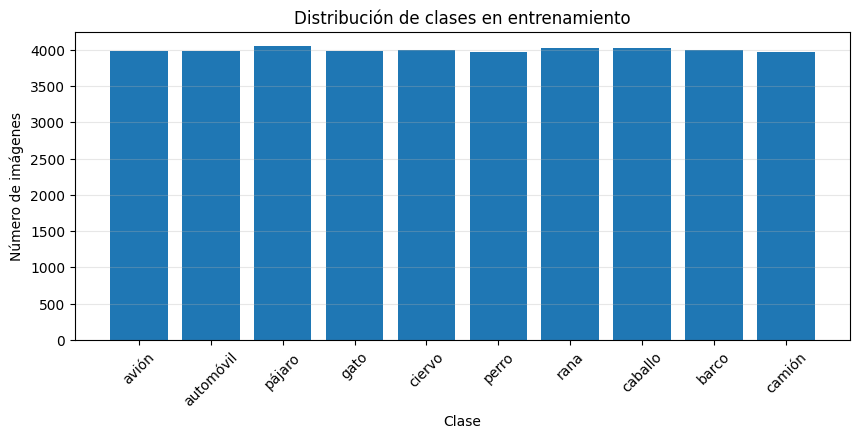

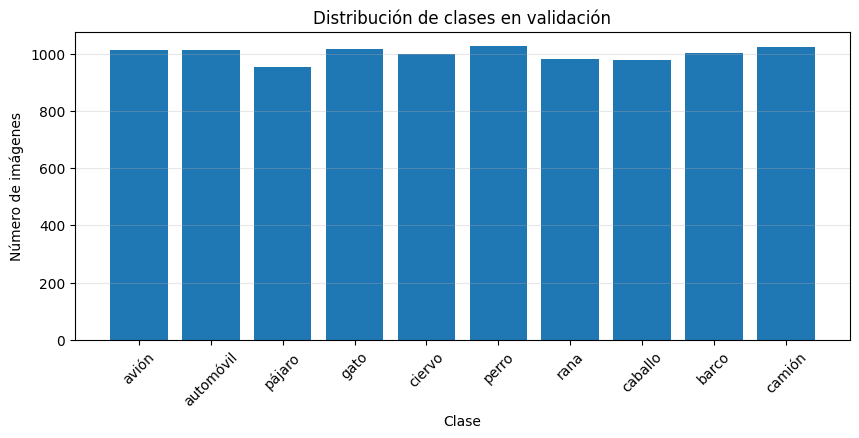

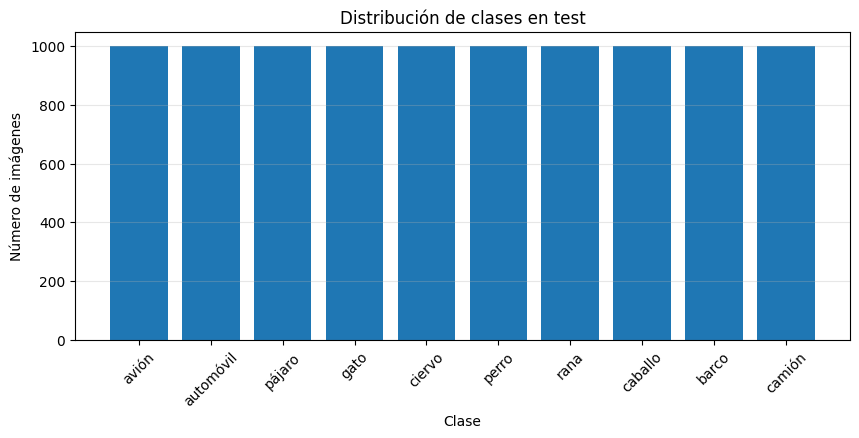

In [8]:
def plot_class_distribution(y, title):
    counts = pd.Series(y).value_counts().sort_index()
    
    plt.figure(figsize=(10, 4))
    plt.bar(class_names, counts.values)
    plt.title(title)
    plt.xlabel("Clase")
    plt.ylabel("Número de imágenes")
    plt.xticks(rotation=45)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

plot_class_distribution(y_train, "Distribución de clases en entrenamiento")
plot_class_distribution(y_val, "Distribución de clases en validación")
plot_class_distribution(y_test, "Distribución de clases en test")

## Visualización de ejemplos

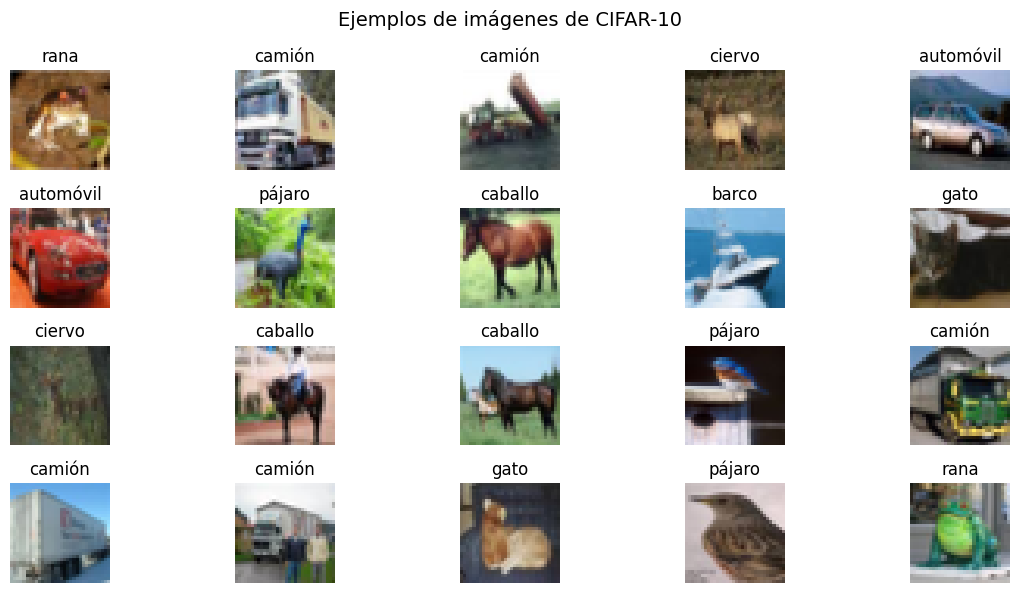

In [9]:
plt.figure(figsize=(12, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Ejemplos de imágenes de CIFAR-10", fontsize=14)
plt.tight_layout()
plt.show()

## Funciones comunes de entrenamiento, evaluación y gráficas

In [10]:
# ============================================================
# Protocolo experimental común
# ============================================================

SEED = 42
MAX_EPOCHS = 50
BATCH_SIZE = 64
LEARNING_RATE = 1e-3

experiment_results = []
histories = {}
trained_models = {}
predictions = {}


def reset_experiment(seed=SEED):
    """Reinicia semillas y limpia sesión para hacer los experimentos más reproducibles."""
    tf.keras.backend.clear_session()
    keras.utils.set_random_seed(seed)

    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


def compile_model(model, learning_rate=LEARNING_RATE):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def get_common_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1
        )
    ]


def run_experiment(
    model_name,
    build_model_fn,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE
):
    """
    Ejecuta un experimento completo con el mismo protocolo para todos los modelos.
    El conjunto de test solo se evalúa al final.
    """
    reset_experiment(SEED)

    model = build_model_fn()
    model = compile_model(model, learning_rate=learning_rate)

    print(f"\nEntrenando modelo: {model_name}")
    model.summary()

    start_time = time.time()

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=get_common_callbacks(),
        verbose=1
    )

    fit_time = time.time() - start_time

    # Evaluación final con los mejores pesos restaurados por EarlyStopping.
    train_loss, train_accuracy = model.evaluate(x_train, y_train, verbose=0)
    val_loss, val_accuracy = model.evaluate(x_val, y_val, verbose=0)
    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    y_pred_proba = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    result = {
        "modelo": model_name,
        "parametros": model.count_params(),
        "epochs_entrenadas": len(history.history["loss"]),
        "best_epoch": best_epoch,
        "tiempo_fit_seg": round(fit_time, 2),
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "test_accuracy": test_accuracy,
        "test_loss": test_loss,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "max_epochs": max_epochs
    }

    experiment_results.append(result)
    histories[model_name] = history.history
    trained_models[model_name] = model
    predictions[model_name] = y_pred

    display(pd.DataFrame([result]).T)

    return model, history, y_pred


def plot_training_curves(model_name):
    h = histories[model_name]
    result = next(r for r in experiment_results if r["modelo"] == model_name)

    test_accuracy = result["test_accuracy"]
    test_loss = result["test_loss"]

    epochs_range = range(1, len(h["loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, h["accuracy"], label="Train accuracy")
    plt.plot(epochs_range, h["val_accuracy"], label="Validation accuracy")
    plt.axhline(test_accuracy, linestyle="--", label="Final test accuracy")
    plt.title(f"Curva de accuracy - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, h["loss"], label="Train loss")
    plt.plot(epochs_range, h["val_loss"], label="Validation loss")
    plt.axhline(test_loss, linestyle="--", label="Final test loss")
    plt.title(f"Curva de pérdida - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def show_results_table():
    results_df = pd.DataFrame(experiment_results)
    results_df = results_df.sort_values("test_accuracy", ascending=False)

    cols = [
        "modelo",
        "parametros",
        "epochs_entrenadas",
        "best_epoch",
        "tiempo_fit_seg",
        "train_accuracy",
        "val_accuracy",
        "test_accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "learning_rate",
        "batch_size"
    ]

    return results_df[cols]

## Modelo 0. Baseline MLP

Model: "M0_MLP_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2375 - loss: 2.0622 - val_accuracy: 0.3171 - val_loss: 1.8832 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.2871 - loss: 1.9263 - val_accuracy: 0.3387 - val_loss: 1.8456 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3026 - loss: 1.8905 - val_accuracy: 0.3300 - val_loss: 1.8432 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.3136 - loss: 1.8652 - val_accuracy: 0.3391 - val_loss: 1.8173 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3200 - loss: 1.8483 - val_accuracy: 0.3709 - val_loss: 1.8019 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3270 - loss: 1.8339 - val_accuracy: 0.3666 - val_loss: 1.7844 - learning_rate: 0.0010
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.3280 - loss: 1.

,0
modelo,M0_MLP_baseline
parametros,1707274
epochs_entrenadas,50
best_epoch,48
tiempo_fit_seg,330.63
train_accuracy,0.476325
val_accuracy,0.4361
test_accuracy,0.4488
test_loss,1.580953
precision_macro,0.466069


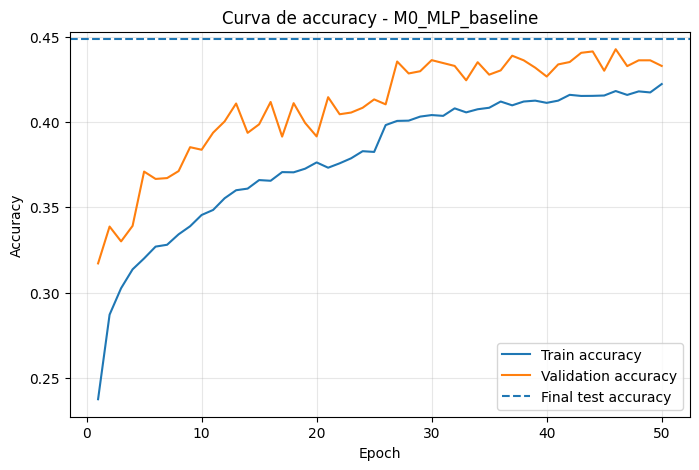

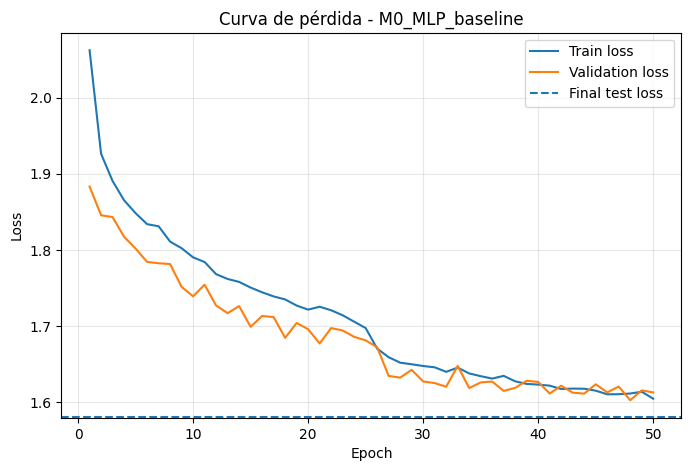

In [11]:
def build_mlp_baseline():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Flatten(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ], name="M0_MLP_baseline")

    return model


mlp_model = build_mlp_baseline()
mlp_model.summary()

mlp_model, mlp_history, mlp_pred = run_experiment(
    model_name="M0_MLP_baseline",
    build_model_fn=build_mlp_baseline
)

plot_training_curves("M0_MLP_baseline")

### Análisis del modelo M0. MLP baseline

El modelo MLP obtiene una accuracy en test de aproximadamente 43.65 %, con un F1 macro de 0.428. Aunque el resultado es superior al azar, sigue siendo limitado para un problema de clasificación de imágenes como CIFAR-10.

La principal limitación del modelo es que aplana las imágenes mediante flatten, convirtiendo cada imagen de 32 × 32 × 3 en un vector unidimensional. Como consecuencia, se pierde la estructura espacial entre píxeles vecinos, que es especialmente relevante en visión por computador.

Las curvas de entrenamiento muestran una mejora progresiva tanto en accuracy como en pérdida. No se observa sobreajuste claro, ya que las métricas de validación y test son incluso ligeramente superiores a las de entrenamiento, esto puede explicarse por el uso de dropout.

En conclusión, este modelo sirvecomo línea base para comparar posteriormente con arquitecturas convolucionales, que deberían obtener mejores resultados al explotar patrones locales de la imagen mediante filtros.

## Modelo 1. CNN simple

Model: "M1_CNN_simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

...

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.4204 - loss: 1.5824 - val_accuracy: 0.5805 - val_loss: 1.2042 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5851 - loss: 1.1725 - val_accuracy: 0.6544 - val_loss: 0.9851 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6500 - loss: 1.0006 - val_accuracy: 0.6926 - val_loss: 0.8889 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6903 - loss: 0.8914 - val_accuracy: 0.7088 - val_loss: 0.8454 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7169 - loss: 0.8085 - val_accuracy: 0.7219 - val_loss: 0.7957 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7405 - loss: 0.7373 - val_accuracy: 0.7193 - val_loss: 0.8000 - learning_rate: 0.0010
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7606 - l

,0
modelo,M1_CNN_simple
parametros,356810
epochs_entrenadas,20
best_epoch,10
tiempo_fit_seg,241.28
train_accuracy,0.868025
val_accuracy,0.7486
test_accuracy,0.7433
test_loss,0.82467
precision_macro,0.742566


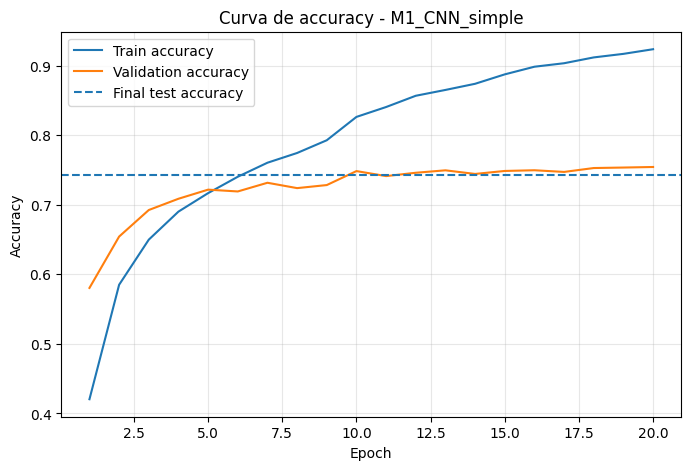

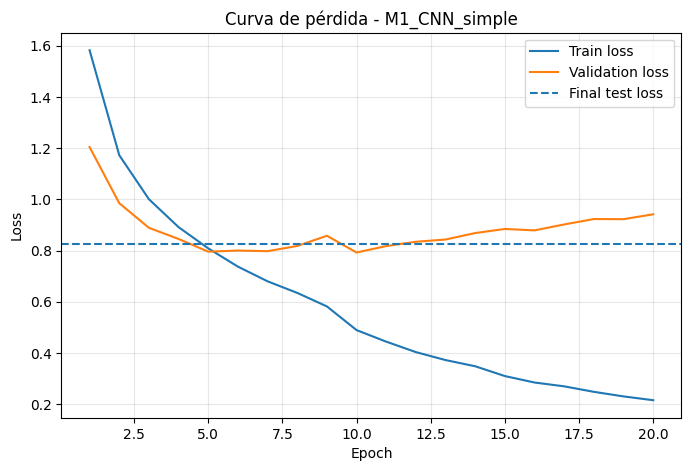

In [12]:
def build_simple_cnn():
    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(64, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),

        layers.Conv2D(128, kernel_size=3, padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=2),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ], name="M1_CNN_simple")

    return model


simple_cnn = build_simple_cnn()
simple_cnn.summary()

simple_cnn, simple_cnn_history, simple_cnn_pred = run_experiment(
    model_name="M1_CNN_simple",
    build_model_fn=build_simple_cnn
)

plot_training_curves("M1_CNN_simple")

### Análisis del modelo M1. CNN simple

El modelo CNN simple mejora de forma muy significativa al baseline MLP. Mientras que el MLP obtiene una accuracy en test de 43.65 %, la CNN simple alcanza aproximadamente 74.91 %, utilizando además muchos menos parámetros. Esto confirma que las capas convolucionales son mucho más adecuadas para CIFAR-10, ya que pueden aprender patrones locales de las imágenes y conservar información espacial.

Sin embargo, las curvas muestran sobreajuste. A partir de las primeras epochs, la accuracy de entrenamiento sigue aumentando hasta superar el 90 %, mientras que las métricas de validación y test se estabilizan alrededor del 75 %. De forma similar, la pérdida de entrenamiento sigue bajando, pero la pérdida de validación/test deja de mejorar y empieza a aumentar.

Por tanto, este modelo demuestra la ventaja de las CNN frente a las redes fully connected, pero todavía necesita regularización adicional para combatir el sobreajuste. En los siguientes modelos se incorporarán técnicas como Batch Normalization, Dropout, regularización L2 y data augmentation para intentar mejorar la generalización.

## M2. CNN regularizada

Model: "M2_CNN_BatchNorm_Dropout_L2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

...

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 87ms/step - accuracy: 0.4380 - loss: 1.6773 - val_accuracy: 0.4509 - val_loss: 1.7638 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.6104 - loss: 1.1984 - val_accuracy: 0.4217 - val_loss: 1.9642 - learning_rate: 0.0010
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 86ms/step - accuracy: 0.6745 - loss: 1.0395 - val_accuracy: 0.6172 - val_loss: 1.2183 - learning_rate: 0.0010
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.7075 - loss: 0.9584 - val_accuracy: 0.5642 - val_loss: 1.3953 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.7319 - loss: 0.9012 - val_accuracy: 0.5765 - val_loss: 1.3844 - learning_rate: 0.0010
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.7501 - loss: 0.8628 - val_accuracy: 0.6007 - val_loss: 1.3486 - learning_rate: 0.0010
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.7665 - l

,0
modelo,M2_CNN_BatchNorm_Dropout_L2
parametros,816938
epochs_entrenadas,50
best_epoch,49
tiempo_fit_seg,2778.5
train_accuracy,0.995925
val_accuracy,0.8804
test_accuracy,0.8706
test_loss,0.641227
precision_macro,0.870596


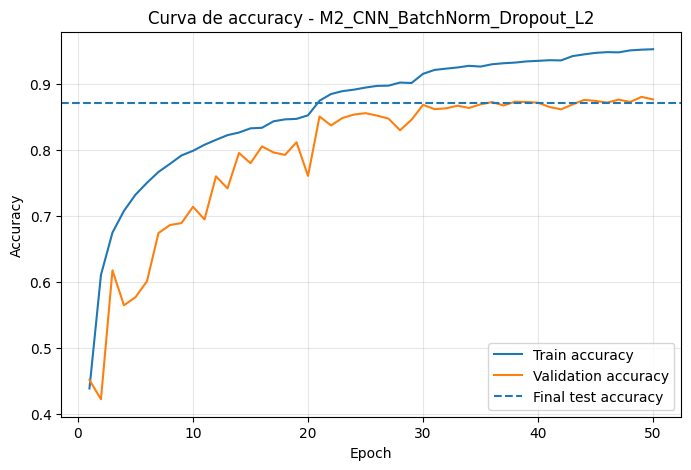

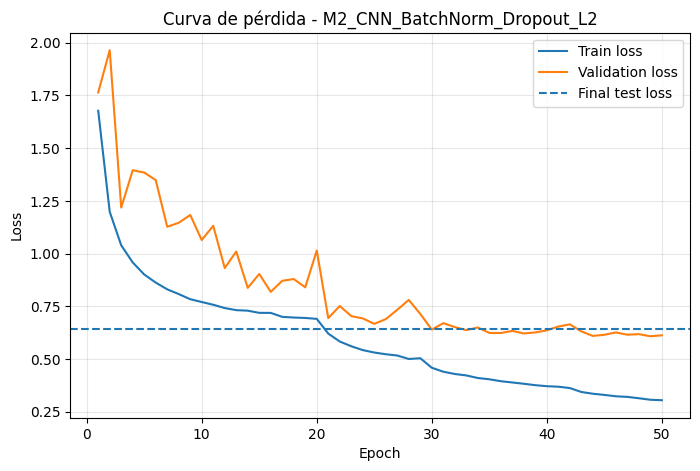

In [13]:
def build_regularized_cnn():
    weight_decay = 1e-4

    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(
            32, kernel_size=3, padding="same",
            kernel_regularizer=regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(
            32, kernel_size=3, padding="same",
            kernel_regularizer=regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.25),

        layers.Conv2D(
            64, kernel_size=3, padding="same",
            kernel_regularizer=regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(
            64, kernel_size=3, padding="same",
            kernel_regularizer=regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.30),

        layers.Conv2D(
            128, kernel_size=3, padding="same",
            kernel_regularizer=regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Conv2D(
            128, kernel_size=3, padding="same",
            kernel_regularizer=regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(pool_size=2),
        layers.Dropout(0.40),

        layers.Flatten(),
        layers.Dense(
            256,
            kernel_regularizer=regularizers.l2(weight_decay)
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.50),

        layers.Dense(num_classes, activation="softmax")
    ], name="M2_CNN_BatchNorm_Dropout_L2")

    return model


regularized_cnn = build_regularized_cnn()
regularized_cnn.summary()

regularized_cnn, regularized_cnn_history, regularized_cnn_pred = run_experiment(
    model_name="M2_CNN_BatchNorm_Dropout_L2",
    build_model_fn=build_regularized_cnn
)

plot_training_curves("M2_CNN_BatchNorm_Dropout_L2")

### Análisis del modelo M2. CNN con Batch Normalization, Dropout y L2

El modelo M2 introduce varias técnicas de regularización y estabilización del entrenamiento sobre la CNN simple. En concreto, se añaden capas de Batch Normalization, Dropout progresivo y regularización L2 en las capas convolucionales y densas.

El resultado mejora de forma clara respecto al modelo M1. La accuracy en test pasa de aproximadamente 74.91 % a 86.78 %, y el F1 macro alcanza 0.8667. El modelo mejora la accuracy global y además mantiene un rendimiento equilibrado entre las distintas clases del dataset.

Las curvas de entrenamiento muestran un comportamiento mucho más estable que en la CNN simple. Aunque la accuracy de entrenamiento sigue siendo ligeramente superior a la de validación y test, la diferencia es pequeña. La pérdida de validación se mantiene estable y baja, sin el incremento claro observado en M1. Esto sugiere que Batch Normalization, Dropout y L2 han reducido significativamente el sobreajuste que era el objetivo.

Como parte negativa, el coste computacional aumenta ya que el modelo tiene más capas y tarda bastante más en entrenarse. Aun así, la mejora de rendimiento justifica esta arquitectura como una candidata perfecta para el modelo final a falta de siguiente modelos de prueba.

## M3. Modelo con Data Augmentation

### Diferencia entre M2 y M3

El modelo M3 mantiene la misma arquitectura que M2 para que la comparación sea controlada. La única diferencia relevante es la incorporación de data augmentation. Asi se puede ver si data augmentation contribuye a un cambio en el rennmdiento de este modleo comparado con M2

La arquitectura se organiza en tres bloques convolucionales con 32, 64 y 128 filtros. Esta progresión permite que las primeras capas aprendan patrones simples, como bordes o colores, mientras que las capas posteriores capturan texturas, formas y patrones más complejos. Tras cada bloque se aplica MaxPooling para reducir progresivamente la resolución espacial de 32x32 a 16x16, 8x8 y 4x4.

Se utilizan dos convoluciones por bloque para extraer más información antes de reducir la resolución. Además, Batch Normalization estabiliza el entrenamiento, Dropout reduce el sobreajuste (apagando ciertas neuronas para evitar sobreajuste) y la regularización L2 penaliza pesos excesivamente grandes. La capa densa final actúa como clasificador sobre las características extraídas por la parte convolucional.

In [ ]:
def build_augmented_regularized_cnn():
    weight_decay = 1e-4

    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomTranslation(
            height_factor=0.10,
            width_factor=0.10,
            seed=SEED
        ),
        layers.RandomRotation(0.05, seed=SEED),
        layers.RandomZoom(0.10, seed=SEED),
    ], name="data_augmentation")

    inputs = keras.Input(shape=(32, 32, 3))

    # Aumento de datos se aplica solo durante entrenamiento
    x = data_augmentation(inputs)

    # Bloque convolucional 1
    x = layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Dropout(0.25)(x)

    # Bloque convolucional 2
    x = layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Dropout(0.30)(x)

    # Bloque convolucional 3
    x = layers.Conv2D(
        128,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        128,
        kernel_size=3,
        padding="same",
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Dropout(0.40)(x)

    # Clasificador
    x = layers.Flatten()(x)

    x = layers.Dense(
        256,
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.50)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="M3_CNN_BN_Dropout_L2_Augmentation"
    )

    return model

In [ ]:
augmented_cnn, augmented_cnn_history, augmented_cnn_pred = run_experiment(
    model_name="M3_CNN_BN_Dropout_L2_Augmentation",
    build_model_fn=build_augmented_regularized_cnn
)

plot_training_curves("M3_CNN_BN_Dropout_L2_Augmentation")

## M4. CNN eficiente con SeparableConv2D

In [ ]:
def build_separable_regularized_cnn():
    weight_decay = 1e-4

    inputs = keras.Input(shape=(32, 32, 3))

    x = layers.SeparableConv2D(
        32,
        kernel_size=3,
        padding="same",
        depthwise_regularizer=regularizers.l2(weight_decay),
        pointwise_regularizer=regularizers.l2(weight_decay)
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.SeparableConv2D(
        32,
        kernel_size=3,
        padding="same",
        depthwise_regularizer=regularizers.l2(weight_decay),
        pointwise_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.SeparableConv2D(
        64,
        kernel_size=3,
        padding="same",
        depthwise_regularizer=regularizers.l2(weight_decay),
        pointwise_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.SeparableConv2D(
        64,
        kernel_size=3,
        padding="same",
        depthwise_regularizer=regularizers.l2(weight_decay),
        pointwise_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Dropout(0.30)(x)

    x = layers.SeparableConv2D(
        128,
        kernel_size=3,
        padding="same",
        depthwise_regularizer=regularizers.l2(weight_decay),
        pointwise_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.SeparableConv2D(
        128,
        kernel_size=3,
        padding="same",
        depthwise_regularizer=regularizers.l2(weight_decay),
        pointwise_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    x = layers.Dropout(0.40)(x)

    x = layers.Flatten()(x)

    x = layers.Dense(
        256,
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.50)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="M4_Separable_CNN_BN_Dropout_L2"
    )

    return model

In [ ]:
separable_cnn, separable_cnn_history, separable_cnn_pred = run_experiment(
    model_name="M4_Separable_CNN_BN_Dropout_L2",
    build_model_fn=build_separable_regularized_cnn
)

plot_training_curves("M4_Separable_CNN_BN_Dropout_L2")

## M5. MobileNetV2 congelado

El modelo M5 utiliza MobileNetV2 preentrenado en ImageNet como extractor de características. Se elimina la capa de clasificación original y se añade una nueva cabeza de clasificación adaptada a las 10 clases de CIFAR-10 para hacer transfer learning.

La parte convolucional se mantiene congelada. Por tanto, solo se entrenan las capas densas finales. Este enfoque permite evaluar si las características visuales aprendidas en ImageNet son útiles para este datatset en particular CIFAR-10 sin modificar los pesos originales del modelo preentrenado.

Las imágenes de CIFAR-10 tienen tamaño 32x32, por lo que se redimensionan a 96x96 antes de entrar en MobileNetV2.

In [ ]:
def build_mobilenetv2_frozen():
    inputs = keras.Input(shape=(32, 32, 3))

    # CIFAR-10 está normalizado en [0, 1]. MobileNetV2 espera [-1, 1].
    x = layers.Resizing(96, 96)(inputs)
    x = layers.Rescaling(2.0, offset=-1.0)(x)

    base_model = keras.applications.MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.30)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="M5_MobileNetV2_Frozen"
    )

    return model

In [ ]:
mobilenet_frozen, mobilenet_frozen_history, mobilenet_frozen_pred = run_experiment(
    model_name="M5_MobileNetV2_Frozen",
    build_model_fn=build_mobilenetv2_frozen
)

plot_training_curves("M5_MobileNetV2_Frozen")

## M6. MobileNetV2 con fine-tuning

In [ ]:
def run_fine_tuning_experiment(
    model_name,
    model,
    base_model_name="mobilenetv2_1.00_96",
    fine_tune_at=100,
    max_epochs=20,
    batch_size=BATCH_SIZE,
    learning_rate=1e-5
):
    """
    Fine-tuning de un modelo transfer learning ya entrenado.
    Se descongelan solo las últimas capas de la base preentrenada.
    """
    base_model = None

    for layer in model.layers:
        if isinstance(layer, keras.Model) and base_model_name in layer.name:
            base_model = layer
            break

    if base_model is None:
        raise ValueError("No se ha encontrado la base MobileNetV2 dentro del modelo.")

    base_model.trainable = True

    # Congelar capas iniciales y entrenar solo las últimas.
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    # Mantener BatchNorm congeladas para evitar inestabilidad en fine-tuning.
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    start_time = time.time()

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=max_epochs,
        batch_size=batch_size,
        callbacks=get_common_callbacks(),
        verbose=1
    )

    fit_time = time.time() - start_time

    train_loss, train_accuracy = model.evaluate(x_train, y_train, verbose=0)
    val_loss, val_accuracy = model.evaluate(x_val, y_val, verbose=0)
    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    y_pred_proba = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)

    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    result = {
        "modelo": model_name,
        "parametros": model.count_params(),
        "epochs_entrenadas": len(history.history["loss"]),
        "best_epoch": best_epoch,
        "tiempo_fit_seg": round(fit_time, 2),
        "train_accuracy": train_accuracy,
        "val_accuracy": val_accuracy,
        "test_accuracy": test_accuracy,
        "test_loss": test_loss,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "max_epochs": max_epochs
    }

    experiment_results.append(result)
    histories[model_name] = history.history
    trained_models[model_name] = model
    predictions[model_name] = y_pred

    display(pd.DataFrame([result]).T)

    return model, history, y_pred

In [ ]:
mobilenet_finetuned, mobilenet_finetuned_history, mobilenet_finetuned_pred = run_fine_tuning_experiment(
    model_name="M6_MobileNetV2_FineTuning",
    model=mobilenet_frozen,
    fine_tune_at=100,
    max_epochs=20,
    batch_size=BATCH_SIZE,
    learning_rate=1e-5
)

plot_training_curves("M6_MobileNetV2_FineTuning")

## Modelo M7. Transfer learning con EfficientNetV2S

El modelo M7 utiliza EfficientNetV2S como arquitectura preentrenada más potente y que aún puede ser ejecutado con la GPU de mi equipo.

En este experimento se utiliza EfficientNetV2S congelado como extractor de características. Las imágenes de CIFAR-10 se redimensionan a 224x224 para adaptarse al tamaño de entrada habitual de este tipo de arquitecturas preentrenadas. La base se mantiene congelada y se entrena únicamente una nueva cabeza de clasificación para las 10 clases del problema.